# Symmetric Group S_n: Spherical Training with Unshared Embedding

This notebook demonstrates Stage 1 training on the **symmetric group S_n** with **unshared embedding** (`share_embed=False`).

**Task**: Permutation composition σ ∘ τ (non-commutative)

**Basis**: Irreducible representations of S_n (Young tableaux)

**Key differences from cyclic groups**:
- Irreps have varying dimensions (not all 1-dimensional)
- Basis indexed by (partition, i, j) where i,j are matrix indices
- Sum of d²_λ over all partitions λ equals |S_n| = n!

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from math import factorial

from src.tasks import SymmetricGroupMultiplication
from src.basis import SymmetricGroupBasis
from src.model import WideNetworkScaleSphere
from src.utils import (
    cross_entropy_high_precision,
    accuracy,
    project_gradient_to_tangent_space,
    normalize_to_pi,
)

# Font settings - use Palatino, no LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'P052', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Custom colormap: blue -> white -> red
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    ['#0D2758', 'white', '#A32015'],
    N=256
)

## 1. Configuration

In [2]:
# === Symmetric Group Configuration ===
N_DEGREE = 4  # S_4 has 24 elements (4! = 24)
              # S_3 has 6 elements (3! = 6)
              # S_5 has 120 elements (5! = 120)

# Model
WIDTH = 128
ACT_TYPE = 'Quad'
INIT_SCALE = 0.5
SHARE_EMBED = False  # Unshared for non-commutative operation

# Training
LR = 1e-3
NUM_EPOCHS = 2000
PRINT_EVERY = 500

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cpu')

vocab_size = factorial(N_DEGREE)
print(f"Symmetric Group: S_{N_DEGREE}")
print(f"Group size: |S_{N_DEGREE}| = {N_DEGREE}! = {vocab_size}")
print(f"Dataset size: {vocab_size}² = {vocab_size**2} pairs")
print(f"Model: width={WIDTH}, activation={ACT_TYPE}, share_embed={SHARE_EMBED}")

Symmetric Group: S_4
Group size: |S_4| = 4! = 24
Dataset size: 24² = 576 pairs
Model: width=128, activation=Quad, share_embed=False


## 2. Initialize Task, Basis, and Model

In [3]:
# Create task and basis
task = SymmetricGroupMultiplication(n=N_DEGREE)
basis = SymmetricGroupBasis(n=N_DEGREE)

print(f"Task: {task}")
print(f"Basis: {basis}")
print(f"\nIrreducible representations (partitions -> dimension):")
for partition, dim in basis.partition_dimensions.items():
    part_str = ','.join(map(str, partition))
    print(f"  [{part_str}]: dim = {dim} -> contributes {dim**2} basis functions")
print(f"\nTotal basis functions: {sum(d**2 for d in basis.partition_dimensions.values())} = {vocab_size}")

Task: SymmetricGroupMultiplication(n=4, vocab_size=24)
Basis: SymmetricGroupBasis(n=4, size=24, irreps={[4]:1, [3,1]:3, [2,2]:2, [2,1,1]:3, [1,1,1,1]:1})

Irreducible representations (partitions -> dimension):
  [4]: dim = 1 -> contributes 1 basis functions
  [3,1]: dim = 3 -> contributes 9 basis functions
  [2,2]: dim = 2 -> contributes 4 basis functions
  [2,1,1]: dim = 3 -> contributes 9 basis functions
  [1,1,1,1]: dim = 1 -> contributes 1 basis functions

Total basis functions: 24 = 24


In [4]:
# Generate data
data, labels = task.generate_all_data(device)

# Create model
model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f"\nModel architecture:")
print(f"  W_in:  {model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {model.W_out.shape}")
print(f"  scale_in:  {model.scale_in.item():.4f}")
print(f"  scale_out: {model.scale_out.item():.4f}")
print(f"\nDataset: {len(data)} samples")


Model architecture:
  W_in:  torch.Size([128, 48])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([24, 128])
  scale_in:  0.5000
  scale_out: 0.5000

Dataset: 576 samples


## 3. Run Stage 1 Training (Projected GD on Sphere)

In [5]:
# Save initial weights before training
W_in_init = model.W_in.detach().cpu().clone()
W_out_init = model.W_out.detach().cpu().clone()

# Freeze scales
model.scale_in.requires_grad = False
model.scale_out.requires_grad = False

# Optimizer for directions only
optimizer = optim.Adam([model.W_in, model.W_out], lr=LR)

# Training history
losses = []
accuracies = []

print("=" * 60)
print("Stage 1: Projected GD (Directions only, Scale fixed)")
print("=" * 60)
print(f"Fixed scale_in = {model.scale_in.item():.4f}, scale_out = {model.scale_out.item():.4f}")

for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    
    # Forward
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc = accuracy(logits, labels)
    
    # Backward
    loss.backward()
    
    # Project gradients onto tangent space
    with torch.no_grad():
        model.W_in.grad = project_gradient_to_tangent_space(
            model.W_in.data, model.W_in.grad, dim=1
        )
        model.W_out.grad = project_gradient_to_tangent_space(
            model.W_out.data, model.W_out.grad, dim=0
        )
    
    # Step
    optimizer.step()
    
    # Project back onto sphere
    model.normalize_directions()
    
    # Record
    losses.append(loss.item())
    accuracies.append(acc)
    
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f}")

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")

Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Epoch     0 | Loss: 1830.558472 | Acc: 0.0347
Epoch   500 | Loss: 1830.167358 | Acc: 0.9983
Epoch  1000 | Loss: 1830.167358 | Acc: 0.9983
Epoch  1500 | Loss: 1830.167236 | Acc: 0.9983

Final | Loss: 1830.167358 | Acc: 0.9983


## 4. Single Frequency Phenomenon (Representation Analysis)

For `share_embed=False`, W_in has shape `(width, 2*vocab_size)` where:
- First half `W_in[:, :vocab_size]` corresponds to position 1 (σ)
- Second half `W_in[:, vocab_size:]` corresponds to position 2 (τ)

The Fourier transform on S_n uses irreducible representations indexed by partitions.

In [6]:
# Get trained weights
W_in = model.W_in.detach().cpu()
W_out = model.W_out.detach().cpu()

# Number of neurons
M = WIDTH
G_ORDER = vocab_size  # |G| = n!

# Split W_in into position 1 and position 2 (trained)
W_in_pos1 = W_in[:, :vocab_size]
W_in_pos2 = W_in[:, vocab_size:]

# Split W_in_init into position 1 and position 2 (initial)
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

print(f"W_in shape: {W_in.shape}")
print(f"W_in_pos1 (σ): {W_in_pos1.shape}")
print(f"W_in_pos2 (τ): {W_in_pos2.shape}")
print(f"W_out: {W_out.shape}")

# Normalize each part (trained)
W_in_pos1_norm = W_in_pos1 / W_in_pos1.norm(dim=1, keepdim=True)
W_in_pos2_norm = W_in_pos2 / W_in_pos2.norm(dim=1, keepdim=True)
W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)

# Normalize each part (initial)
W_in_init_pos1_norm = W_in_init_pos1 / W_in_init_pos1.norm(dim=1, keepdim=True)
W_in_init_pos2_norm = W_in_init_pos2 / W_in_init_pos2.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

# Apply Fourier transform with paper's L²(G) scaling (trained)
# ν̂[ρ] = C[ρ] / √(|G|·d_ρ)
W_in_pos1_dft = basis.transform_paper(W_in_pos1_norm)
W_in_pos2_dft = basis.transform_paper(W_in_pos2_norm)
W_out_dft = basis.transform_paper(W_out_norm.T)

# Apply Fourier transform (initial)
W_in_init_pos1_dft = basis.transform_paper(W_in_init_pos1_norm)
W_in_init_pos2_dft = basis.transform_paper(W_in_init_pos2_norm)
W_out_init_dft = basis.transform_paper(W_out_init_norm.T)

# Get magnitudes (trained)
W_in_pos1_mag = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag = torch.abs(W_in_pos2_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()

# Get magnitudes (initial)
W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"\nDFT shapes (paper notation ν̂[ρ] via basis.transform_paper()):")
print(f"W_in_pos1_dft: {W_in_pos1_dft.shape}")
print(f"W_in_pos2_dft: {W_in_pos2_dft.shape}")
print(f"W_out_dft: {W_out_dft.shape}")

# Compute partition boundaries for grouping
partition_boundaries = []
partition_labels = []
curr_idx = 0
for partition in basis.partitions:
    dim = basis.partition_dimensions[partition]
    partition_boundaries.append((curr_idx, curr_idx + dim * dim))
    part_str = ','.join(map(str, partition))
    partition_labels.append(f"[{part_str}]\n(d={dim})")
    curr_idx += dim * dim

print(f"\nPartition blocks: {partition_boundaries}")

# Verify Plancherel: Σ_ρ d_ρ ||ν̂[ρ]||²_F = 1/|G| for unit-norm signals
print(f"\nVerification (Plancherel): Σ_ρ d_ρ ||ν̂[ρ]||²_F should = 1/|G| = {1/G_ORDER:.6f}")
total_energy = 0
for partition in basis.partitions:
    d = basis.partition_dimensions[partition]
    start, end = partition_boundaries[list(basis.partitions).index(partition)]
    block = W_in_pos1_dft[0, start:end].numpy().reshape(d, d)
    energy = d * np.linalg.norm(block, 'fro')**2
    total_energy += energy
    part_str = ','.join(map(str, partition))
    print(f"  [{part_str}]: d={d}, d·||ν̂||²_F = {energy:.6f}")
print(f"  Total: {total_energy:.6f}")

W_in shape: torch.Size([128, 48])
W_in_pos1 (σ): torch.Size([128, 24])
W_in_pos2 (τ): torch.Size([128, 24])
W_out: torch.Size([24, 128])

DFT shapes (paper notation ν̂[ρ] via basis.transform_paper()):
W_in_pos1_dft: torch.Size([128, 24])
W_in_pos2_dft: torch.Size([128, 24])
W_out_dft: torch.Size([128, 24])

Partition blocks: [(0, 1), (1, 10), (10, 14), (14, 23), (23, 24)]

Verification (Plancherel): Σ_ρ d_ρ ||ν̂[ρ]||²_F should = 1/|G| = 0.041667
  [4]: d=1, d·||ν̂||²_F = 0.000000
  [3,1]: d=3, d·||ν̂||²_F = 0.000000
  [2,2]: d=2, d·||ν̂||²_F = 0.000000
  [2,1,1]: d=3, d·||ν̂||²_F = 0.041667
  [1,1,1,1]: d=1, d·||ν̂||²_F = 0.000000
  Total: 0.041667


### 4.1 Single Representation Phenomenon (Representation-Level View)

Unlike cyclic groups where each irrep is 1-dimensional, S_n has irreps of varying dimensions.
The "single frequency" phenomenon here means neurons specialize to a **single irreducible representation** (partition).

We compute the L²(G) energy in each irrep block using paper's Plancherel formula:
$$E_\lambda^{(m)} = d_\lambda \|\hat{\nu}_m[\lambda]\|_F^2$$

By Plancherel: $\sum_\lambda E_\lambda^{(m)} = \|\nu_m\|_{L^2(G)}^2 = \frac{1}{|G|}$ for unit-norm signals.

In [7]:
# Compute L²(G) energy per representation: E_ρ = d_ρ ||ν̂[ρ]||²_F
def compute_irrep_energy(mag_matrix, boundaries, partitions, partition_dims):
    """Compute L²(G) energy d_ρ ||ν̂[ρ]||²_F in each irrep block."""
    n_neurons = mag_matrix.shape[0]
    n_irreps = len(boundaries)
    energy = np.zeros((n_neurons, n_irreps))
    
    for i, (start, end) in enumerate(boundaries):
        partition = list(partitions)[i]
        d = partition_dims[partition]
        # E_ρ = d_ρ ||ν̂[ρ]||²_F
        energy[:, i] = d * np.sum(mag_matrix[:, start:end] ** 2, axis=1)
    
    return energy

# Compute energies (trained and init)
energy_pos1 = compute_irrep_energy(W_in_pos1_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)
energy_pos2 = compute_irrep_energy(W_in_pos2_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)
energy_out = compute_irrep_energy(W_out_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)

energy_pos1_init = compute_irrep_energy(W_in_init_pos1_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)
energy_pos2_init = compute_irrep_energy(W_in_init_pos2_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)
energy_out_init = compute_irrep_energy(W_out_init_mag, partition_boundaries, basis.partitions, basis.partition_dimensions)

print("L²(G) energy E_ρ = d_ρ ||ν̂[ρ]||²_F per irrep (first 8 neurons, position 1):")
print(f"(By Plancherel, Σ_ρ E_ρ = 1/|G| = 1/{G_ORDER} ≈ {1/G_ORDER:.4f})")
print(f"\n{'Neuron':<8}", end="")
for label in partition_labels:
    print(f"{label.split(chr(10))[0]:<12}", end="")
print(f"{'Sum':<12}")
print("-" * 80)
for m in range(8):
    print(f"{m:<8}", end="")
    row_sum = 0
    for e in energy_pos1[m]:
        print(f"{e:<12.4f}", end="")
        row_sum += e
    print(f"{row_sum:<12.4f}")

L²(G) energy E_ρ = d_ρ ||ν̂[ρ]||²_F per irrep (first 8 neurons, position 1):
(By Plancherel, Σ_ρ E_ρ = 1/|G| = 1/24 ≈ 0.0417)

Neuron  [4]         [3,1]       [2,2]       [2,1,1]     [1,1,1,1]   Sum         
--------------------------------------------------------------------------------
0       0.0000      0.0000      0.0000      0.0417      0.0000      0.0417      
1       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      
2       0.0000      0.0000      0.0000      0.0417      0.0000      0.0417      
3       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      
4       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      
5       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      
6       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      
7       0.0000      0.0417      0.0000      0.0000      0.0000      0.0417      


### 4.2 Fine-Grained View: Individual Basis Functions

This shows the detailed view at the individual basis function level (ρ_λ(g)_{ij}), with partition boundaries marked by dotted lines.

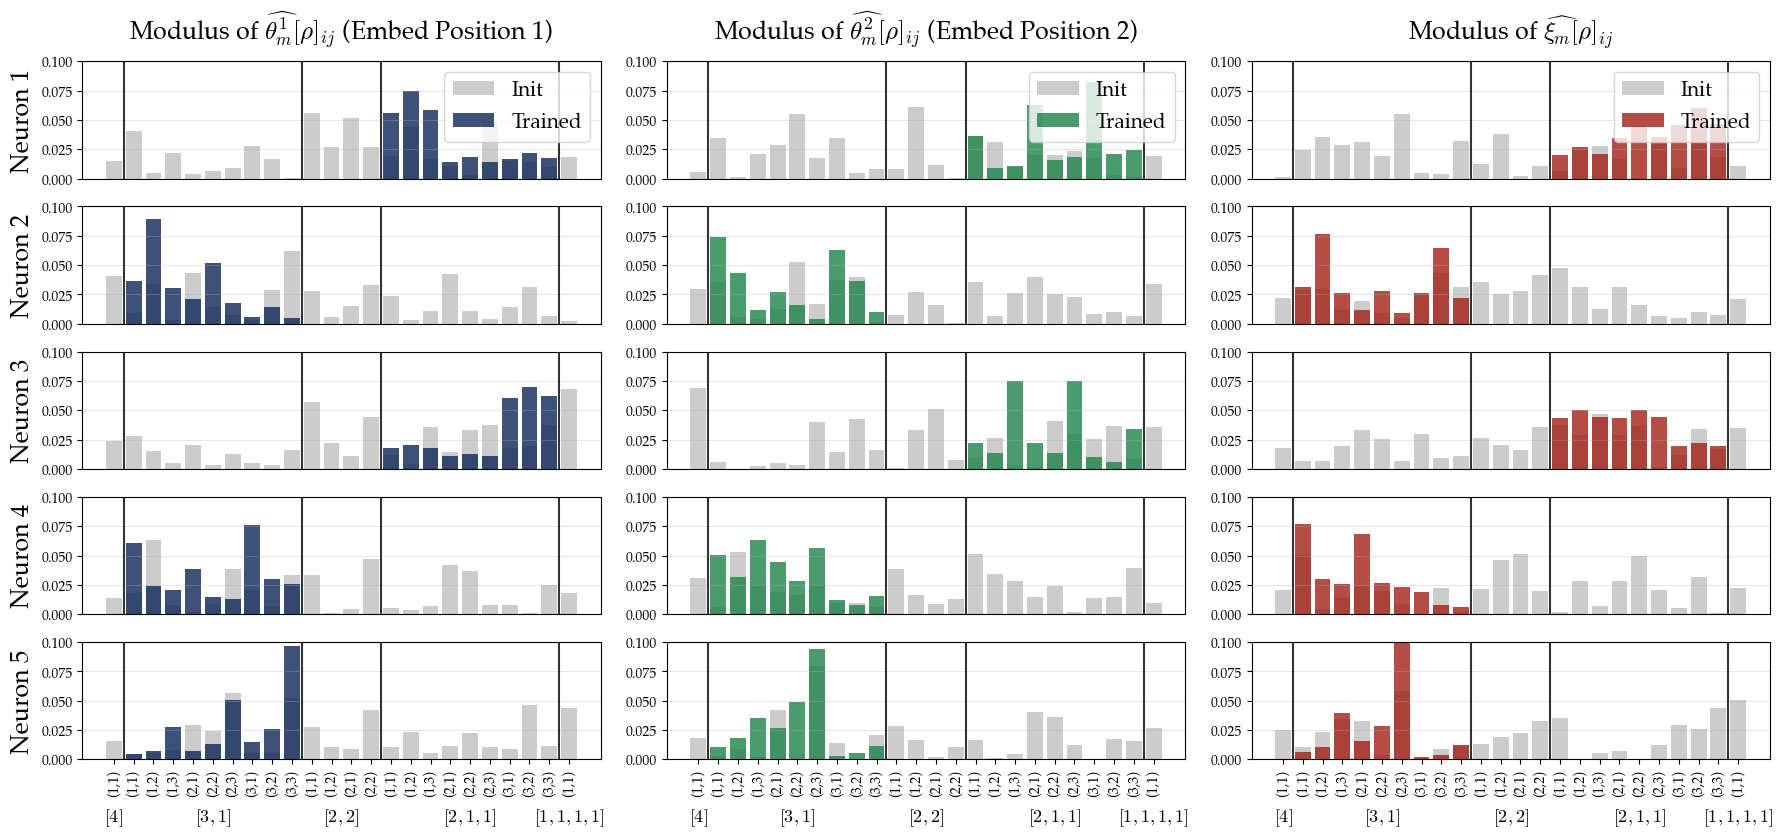

In [8]:
# Plot DFT magnitudes for first 5 neurons
freq_indices = np.arange(vocab_size)
num_neurons_to_show = 5

# Build basis labels (i,j) for each frequency (1-based indexing)
basis_labels = []
for partition in basis.partitions:
    d = basis.partition_dimensions[partition]
    for i in range(d):
        for j in range(d):
            basis_labels.append(f'({i+1},{j+1})')

# Compute center position for each irrep block
irrep_centers = []
for start, end in partition_boundaries:
    center = (start + end - 1) / 2
    irrep_centers.append(center)

# Map partition labels to LaTeX notation
partition_latex_labels = {}
for partition in basis.partitions:
    part_str = ','.join(map(str, partition))
    partition_latex_labels[partition] = f'$[{part_str}]$'

fig, axes = plt.subplots(num_neurons_to_show, 3, figsize=(18, 1.8 * num_neurons_to_show))

for row in range(num_neurons_to_show):
    m = row
    is_last_row = (row == num_neurons_to_show - 1)
    
    # Position 1 - Blue
    ax = axes[row, 0]
    ax.bar(freq_indices, W_in_init_pos1_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos1_mag[m], alpha=0.8, color='#0D2758', label='Trained')
    for start, end in partition_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylabel(f'Neuron {m+1}', fontsize=18)
    ax.set_ylim(0, .1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\theta_m^1}[\rho]_{ij}$ (Embed Position 1)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, partition) in enumerate(zip(irrep_centers, basis.partitions)):
            ax.annotate(partition_latex_labels[partition], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Position 2 - Green
    ax = axes[row, 1]
    ax.bar(freq_indices, W_in_init_pos2_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_in_pos2_mag[m], alpha=0.8, color='#1E8449', label='Trained')
    for start, end in partition_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, .1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\theta_m^2}[\rho]_{ij}$ (Embed Position 2)', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, partition) in enumerate(zip(irrep_centers, basis.partitions)):
            ax.annotate(partition_latex_labels[partition], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])
    
    # Output - Red
    ax = axes[row, 2]
    ax.bar(freq_indices, W_out_init_mag[m], alpha=0.4, color='gray', label='Init')
    ax.bar(freq_indices, W_out_mag[m], alpha=0.8, color='#A32015', label='Trained')
    for start, end in partition_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylim(0, .1)
    ax.grid(True, alpha=0.3, axis='y')
    if row == 0:
        ax.set_title(r'Modulus of $\widehat{\xi_m}[\rho]_{ij}$', fontsize=18, pad=15)
        ax.legend(loc='upper right', fontsize=15)
    if is_last_row:
        ax.set_xticks(freq_indices)
        ax.set_xticklabels(basis_labels, fontsize=10, rotation=90)
        for i, (center, partition) in enumerate(zip(irrep_centers, basis.partitions)):
            ax.annotate(partition_latex_labels[partition], xy=(center, -0.40), xycoords=('data', 'axes fraction'),
                       ha='center', va='top', fontsize=13, fontweight='bold')
    else:
        ax.set_xticks([])

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('../figures/symmetric_group_dft_magnitude.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

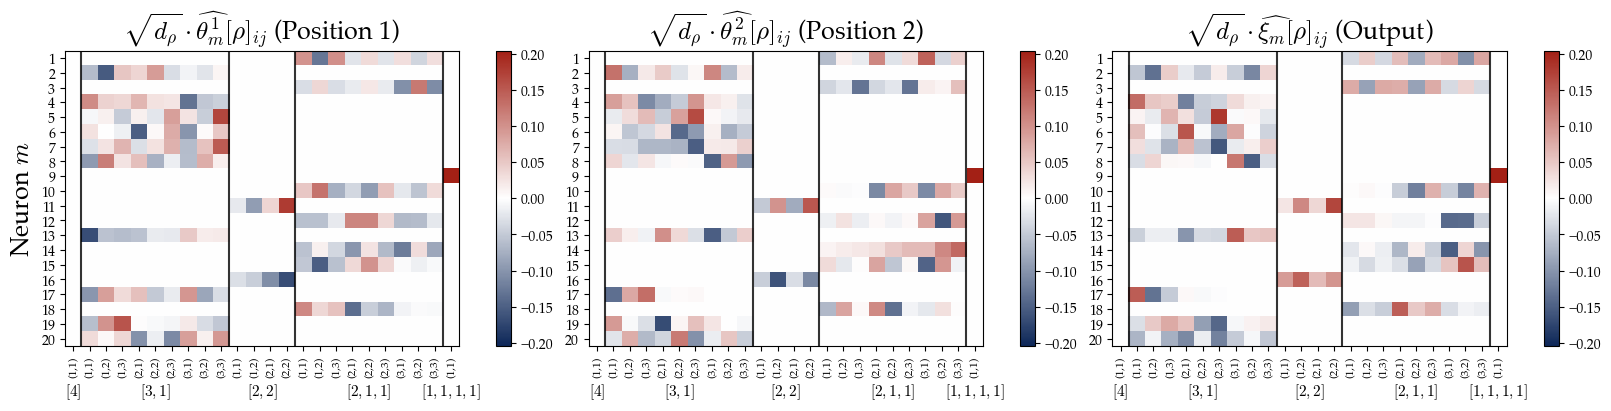

In [9]:
# Heatmap view: DFT coefficients for all neurons (1x3 grid - real only since S_n has real irreps)
# y-axis: neurons, x-axis: basis functions (frequencies)
# Plotting √d_ρ × ν̂[ρ] to show Plancherel-weighted coefficients

num_components = 20  # Number of neurons to show (adjustable)

# Build basis labels for x-axis
basis_labels_short = []
for partition in basis.partitions:
    d = basis.partition_dimensions[partition]
    for i in range(d):
        for j in range(d):
            basis_labels_short.append(f'({i+1},{j+1})')

x_locs = np.arange(vocab_size)
y_locs = np.arange(num_components)

# Scale DFT coefficients by √d_ρ for each irrep block
def scale_by_sqrt_d(dft_coeffs):
    """Scale each irrep block by √d_ρ."""
    scaled = dft_coeffs.clone()
    curr_idx = 0
    for partition in basis.partitions:
        d = basis.partition_dimensions[partition]
        block_size = d * d
        scaled[:, curr_idx:curr_idx + block_size] *= np.sqrt(d)
        curr_idx += block_size
    return scaled

# Apply √d_ρ scaling
W_in_pos1_dft_scaled = scale_by_sqrt_d(W_in_pos1_dft[:num_components])
W_in_pos2_dft_scaled = scale_by_sqrt_d(W_in_pos2_dft[:num_components])
W_out_dft_scaled = scale_by_sqrt_d(W_out_dft[:num_components])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

# Get scaled DFT coefficients (real only for symmetric group)
data_pos1_re = W_in_pos1_dft_scaled.real.numpy()
data_pos2_re = W_in_pos2_dft_scaled.real.numpy()
data_out_re = W_out_dft_scaled.real.numpy()

# Compute vmax for each column
vmax_pos1 = max(np.abs(data_pos1_re).max(), 0.1)
vmax_pos2 = max(np.abs(data_pos2_re).max(), 0.1)
vmax_out = max(np.abs(data_out_re).max(), 0.1)

titles = [r'$\sqrt{d_\rho}\cdot\widehat{\theta_m^1}[\rho]_{ij}$ (Position 1)', r'$\sqrt{d_\rho}\cdot\widehat{\theta_m^2}[\rho]_{ij}$ (Position 2)', r'$\sqrt{d_\rho}\cdot\widehat{\xi_m}[\rho]_{ij}$ (Output)']
data_list = [data_pos1_re, data_pos2_re, data_out_re]
vmax_list = [vmax_pos1, vmax_pos2, vmax_out]

# Compute center position for each irrep block
irrep_centers = []
for start, end in partition_boundaries:
    center = (start + end - 1) / 2
    irrep_centers.append(center)

for col in range(3):
    ax = axes[col]
    data = data_list[col]
    vmax = vmax_list[col]
    
    im = ax.imshow(data, cmap=blue_white_red, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(titles[col], fontsize=18)
    
    # Y-axis label only on first column
    if col == 0:
        ax.set_ylabel('Neuron $m$', fontsize=18)
    
    ax.set_xticks(x_locs)
    ax.set_xticklabels(basis_labels_short, rotation=90, fontsize=8)
    ax.set_yticks(y_locs)
    ax.set_yticklabels(y_locs + 1)
    
    # Add irrep boundary lines
    for start, end in partition_boundaries:
        if start > 0:
            ax.axvline(x=start-0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    
    # Add irrep labels at bottom
    for center, partition in zip(irrep_centers, basis.partitions):
        part_str = ','.join(map(str, partition))
        ax.annotate(f'$[{part_str}]$', xy=(center, -0.12), xycoords=('data', 'axes fraction'),
                   ha='center', va='top', fontsize=11, fontweight='bold')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.savefig('../figures/symmetric_group_dft_heatmap.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 5. Phase Alignment via Matrix Product

For cyclic groups with unshared embedding, the phase relationship $\phi_{in}^{(1)} + \phi_{in}^{(2)} \approx \psi_{out}$ can be expressed as:
$$\hat{z}_{in}^{(1)} \cdot \hat{z}_{in}^{(2)} \cdot (\hat{z}_{out})^* \in \mathbb{R}$$

For the **symmetric group**, Fourier coefficients are **matrices** (for irreps with $d_\lambda > 1$). We compare **two orderings**:

1. **Order 1**: $\hat{W}_{in}^{(1)}(\lambda) \cdot \hat{W}_{in}^{(2)}(\lambda) \cdot \hat{W}_{out}(\lambda)^\dagger$
2. **Order 2**: $\hat{W}_{in}^{(2)}(\lambda) \cdot \hat{W}_{in}^{(1)}(\lambda) \cdot \hat{W}_{out}(\lambda)^\dagger$

Since S_n is **non-commutative**, these may differ. The task computes $\sigma \circ \tau$ (position 1 applied after position 2), so we expect one ordering to be "more real" than the other.

In [10]:
# Extract matrix-valued Fourier coefficients ν̂[ρ] for each irrep (paper notation)
def extract_irrep_matrices(dft_coeffs, partitions, partition_dims):
    """
    Extract d_λ × d_λ matrices from flattened DFT coefficients.
    
    Args:
        dft_coeffs: shape (n_neurons, |G|) - flattened Fourier coefficients
        partitions: list of partitions
        partition_dims: dict mapping partition -> dimension
    
    Returns:
        dict mapping partition -> array of shape (n_neurons, d_λ, d_λ)
    """
    n_neurons = dft_coeffs.shape[0]
    irrep_matrices = {}
    
    curr_idx = 0
    for partition in partitions:
        d = partition_dims[partition]
        # Extract d² coefficients and reshape to (n_neurons, d, d)
        block = dft_coeffs[:, curr_idx:curr_idx + d*d]
        irrep_matrices[partition] = block.reshape(n_neurons, d, d)
        curr_idx += d * d
    
    return irrep_matrices

# Extract matrices for each position and output (paper notation ν̂[ρ])
W_in_pos1_matrices = extract_irrep_matrices(W_in_pos1_dft.numpy(), basis.partitions, basis.partition_dimensions)
W_in_pos2_matrices = extract_irrep_matrices(W_in_pos2_dft.numpy(), basis.partitions, basis.partition_dimensions)
W_out_matrices = extract_irrep_matrices(W_out_dft.numpy(), basis.partitions, basis.partition_dimensions)

print("Extracted irrep matrices (paper notation ν̂[ρ]):")
for partition, mat in W_in_pos1_matrices.items():
    d = basis.partition_dimensions[partition]
    part_str = ','.join(map(str, partition))
    print(f"  [{part_str}]: shape = {mat.shape} (neurons × {d} × {d})")

Extracted irrep matrices (paper notation ν̂[ρ]):
  [4]: shape = (128, 1, 1) (neurons × 1 × 1)
  [3,1]: shape = (128, 3, 3) (neurons × 3 × 3)
  [2,2]: shape = (128, 2, 2) (neurons × 2 × 2)
  [2,1,1]: shape = (128, 3, 3) (neurons × 3 × 3)
  [1,1,1,1]: shape = (128, 1, 1) (neurons × 1 × 1)


### 5.1 Fourier Coefficient Product Structure

We check if $\widehat{\theta}^2_m[\lambda] \cdot \widehat{\theta}^1_m[\lambda] \propto \widehat{\xi}_m[\lambda]$

**Notation:** All DFT coefficients use paper's L²(G) convention:
$$\hat{\nu}[\lambda] = \frac{1}{|G|} \sum_{\sigma \in S_n} \nu(\sigma) \rho_\lambda(\sigma^{-1})$$
These are converted from the code's Euclidean coefficients via $\hat{\nu}[\lambda] = C[\lambda] / \sqrt{|G| \cdot d_\lambda}$.

Selected neurons and their dominant irreps:
  Neuron 1: [2,1,1] (dim=3)
  Neuron 2: [3,1] (dim=3)
  Neuron 3: [2,1,1] (dim=3)
  Neuron 4: [3,1] (dim=3)
  Neuron 5: [3,1] (dim=3)
  Neuron 9: [1,1,1,1] (dim=1)


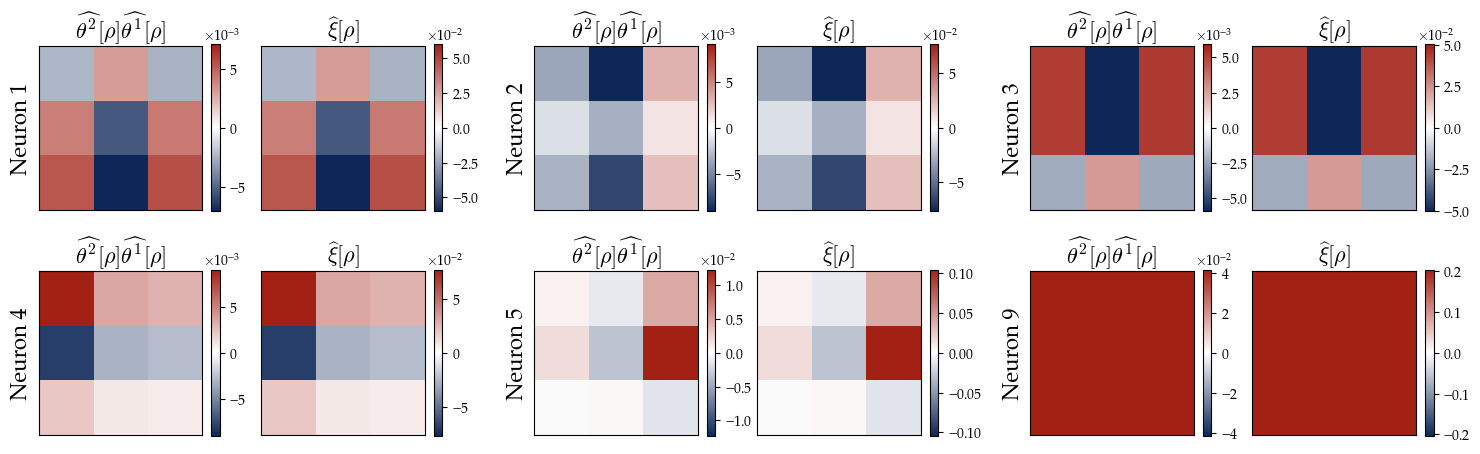


Proportionality check: W2 @ W1 ≈ c · Wout
Neuron     Irrep           Residual        Status         
------------------------------------------------------------
1          [2,1,1]         0.0001          ✓ Aligned      
2          [3,1]           0.0001          ✓ Aligned      
3          [2,1,1]         0.0001          ✓ Aligned      
4          [3,1]           0.0001          ✓ Aligned      
5          [3,1]           0.0001          ✓ Aligned      
9          [1,1,1,1]       0.0000          ✓ Aligned      


In [11]:
# Compare W2 @ W1 vs Wout for selected neurons
# Grid layout: 2n neurons -> n neurons per row, 2 rows
# Columns alternate: neuron1 product, neuron1 xi, gap, neuron2 product, neuron2 xi, ...
# Automatically detects which irrep each neuron specializes in

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

# ============ USER CONFIGURATION ============
# Select neurons by their IDs (0-indexed)
# If 2n neurons, will be arranged as n neurons per row × 2 rows
selected_neuron_ids = [0, 1, 2, 3, 4, 8]  # Pick any even number of neurons
# ============================================

# LaTeX labels for partitions
def partition_to_latex(partition):
    part_str = ','.join(map(str, partition))
    return f'[{part_str}]'

def get_dominant_irrep(neuron_idx):
    """Find which irrep a neuron specializes in (highest energy)."""
    energies = energy_pos1[neuron_idx]
    dominant_idx = np.argmax(energies)
    return list(basis.partitions)[dominant_idx]

def add_colorbar_scientific(fig, im, ax):
    """Add colorbar with scientific notation (10^{-n} scale), offset text moved right."""
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.ticklabel_format(style='scientific', scilimits=(-2, 2))
    # Move the exponent label (×10^n) to the right
    cbar.ax.yaxis.get_offset_text().set_x(3.5)
    return cbar

# Detect irrep for each selected neuron
neuron_irreps = [(m, get_dominant_irrep(m)) for m in selected_neuron_ids]
print("Selected neurons and their dominant irreps:")
for m, partition in neuron_irreps:
    d = basis.partition_dimensions[partition]
    print(f"  Neuron {m+1}: {partition_to_latex(partition)} (dim={d})")

# Calculate grid dimensions: 2n neurons -> n per row, 2 rows
n_neurons = len(selected_neuron_ids)
n_rows = 2
neurons_per_row = (n_neurons + 1) // 2  # Ceiling division for odd numbers

# Build width_ratios: [prod, xi, gap, prod, xi, gap, ...] for neurons_per_row neurons
width_ratios = []
for i in range(neurons_per_row):
    width_ratios.extend([1, 1])
    if i < neurons_per_row - 1:
        width_ratios.append(0.05)  # gap between neuron pairs

# Create figure with GridSpec
fig = plt.figure(figsize=(6 * neurons_per_row, 3 * n_rows))
gs = GridSpec(n_rows, len(width_ratios), figure=fig, 
              width_ratios=width_ratios,
              hspace=-0.05, wspace=0.3)

# Map position within row to grid columns
col_map = []
col_idx = 0
for i in range(neurons_per_row):
    col_map.append((col_idx, col_idx + 1))  # (product_col, xi_col)
    col_idx += 2
    if i < neurons_per_row - 1:
        col_idx += 1  # skip gap column

for i, (m, partition) in enumerate(neuron_irreps):
    row = i // neurons_per_row
    pos_in_row = i % neurons_per_row
    
    d = basis.partition_dimensions[partition]
    
    W1 = W_in_pos1_matrices[partition][m]
    W2 = W_in_pos2_matrices[partition][m]
    Wout = W_out_matrices[partition][m]
    
    # W2 @ W1 (paper's convention)
    W2_W1 = W2 @ W1
    
    col_product, col_xi = col_map[pos_in_row]
    
    # W2@W1 Real - independent colorbar
    ax = fig.add_subplot(gs[row, col_product])
    vmax_w2w1 = max(np.abs(W2_W1.real).max(), 1e-10)
    im = ax.imshow(W2_W1.real, cmap=blue_white_red, vmin=-vmax_w2w1, vmax=vmax_w2w1)
    ax.set_title(r'$\widehat{\theta^2}[\rho]\widehat{\theta^1}[\rho]$', fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=16)
    add_colorbar_scientific(fig, im, ax)
    
    # Wout Real - independent colorbar
    ax = fig.add_subplot(gs[row, col_xi])
    vmax_wout = max(np.abs(Wout.real).max(), 1e-10)
    im = ax.imshow(Wout.real, cmap=blue_white_red, vmin=-vmax_wout, vmax=vmax_wout)
    ax.set_title(r'$\widehat{\xi}[\rho]$', fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

plt.savefig('../figures/symmetric_group_fourier_product.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\nProportionality check: W2 @ W1 ≈ c · Wout")
print("=" * 60)
print(f"{'Neuron':<10} {'Irrep':<15} {'Residual':<15} {'Status':<15}")
print("-" * 60)
for m, partition in neuron_irreps:
    W1 = W_in_pos1_matrices[partition][m]
    W2 = W_in_pos2_matrices[partition][m]
    Wout = W_out_matrices[partition][m]
    
    W2_W1 = W2 @ W1
    W2_W1_norm = W2_W1 / (np.linalg.norm(W2_W1, 'fro') + 1e-10)
    Wout_norm = Wout / (np.linalg.norm(Wout, 'fro') + 1e-10)
    residual = np.linalg.norm(W2_W1_norm - Wout_norm, 'fro')
    status = "✓ Aligned" if residual < 0.1 else "✗ Misaligned"
    
    print(f"{m+1:<10} {partition_to_latex(partition):<15} {residual:<15.4f} {status:<15}")

## 6. Representation Distribution Analysis

Which irreducible representations do neurons specialize to?

In [12]:
# Count which partition each neuron specializes to
partition_counts = {p: 0 for p in basis.partitions}

for m in range(M):
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    
    # Find which partition this frequency belongs to
    curr_idx = 0
    for partition in basis.partitions:
        dim = basis.partition_dimensions[partition]
        if dom_freq < curr_idx + dim * dim:
            partition_counts[partition] += 1
            break
        curr_idx += dim * dim

print("Neuron specialization by irreducible representation:")
print("=" * 50)
for partition, count in partition_counts.items():
    dim = basis.partition_dimensions[partition]
    part_str = ','.join(map(str, partition))
    print(f"  [{part_str}] (dim={dim}): {count} neurons ({100*count/M:.1f}%)")

Neuron specialization by irreducible representation:
  [4] (dim=1): 0 neurons (0.0%)
  [3,1] (dim=3): 42 neurons (32.8%)
  [2,2] (dim=2): 29 neurons (22.7%)
  [2,1,1] (dim=3): 47 neurons (36.7%)
  [1,1,1,1] (dim=1): 10 neurons (7.8%)


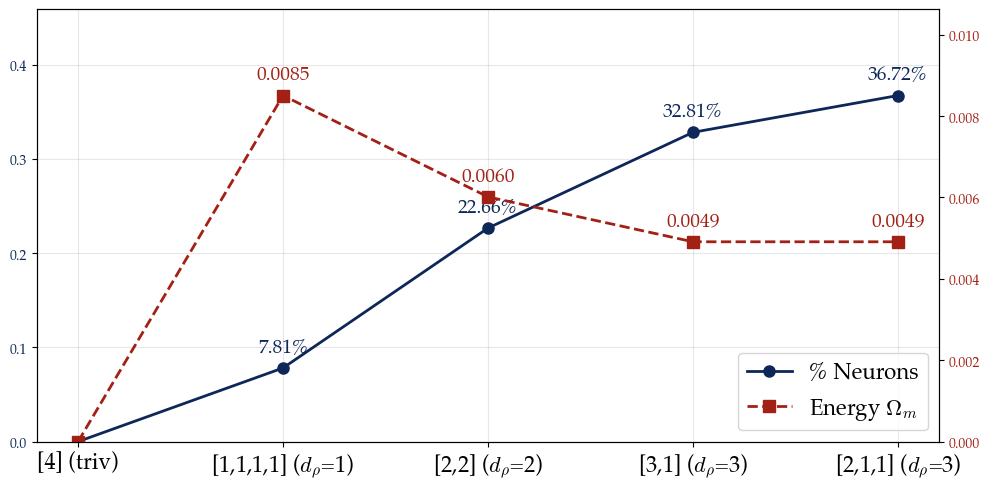


Summary (sorted by proportion):
Irrep           Proportion      Mean Ω_m       
------------------------------------------------------------
[4]            0.0000          0.000000       
[1,1,1,1]      0.0781          0.008505       
[2,2]          0.2266          0.006014       
[3,1]          0.3281          0.004910       
[2,1,1]        0.3672          0.004910       


In [13]:
# Line plot: Proportion of neurons per irrep and Ω_m per irrep
# Ω_m = Σ_{ρ≠1} d_ρ · tr(θ̂²_m[ρ] θ̂¹_m[ρ] ξ̂_m[ρ]*)
# For neurons specializing to a single irrep ρ, only that irrep contributes significantly

def compute_omega_m(m):
    """Compute Ω_m for neuron m using paper notation."""
    omega = 0.0
    for partition in basis.partitions:
        if partition == (N_DEGREE,):  # Skip trivial irrep [n]
            continue
        d = basis.partition_dimensions[partition]
        theta1 = W_in_pos1_matrices[partition][m]  # ν̂[ρ]
        theta2 = W_in_pos2_matrices[partition][m]
        xi = W_out_matrices[partition][m]
        # Ω_m contribution: d_ρ · tr(θ̂² θ̂¹ ξ̂*)
        omega += d * np.real(np.trace(theta2 @ theta1 @ xi.conj().T))
    return omega

# Group neurons by their dominant irrep
neurons_by_irrep = {p: [] for p in basis.partitions}
for m in range(M):
    dom_freq = basis.get_dominant_frequency(W_in_pos1_dft[m])
    curr_idx = 0
    for partition in basis.partitions:
        dim = basis.partition_dimensions[partition]
        if dom_freq < curr_idx + dim * dim:
            neurons_by_irrep[partition].append(m)
            break
        curr_idx += dim * dim

# Compute proportion and mean Ω_m for each irrep
irrep_data = []  # List of (partition, proportion, omega_mean)

for partition in basis.partitions:
    count = partition_counts[partition]
    prop = count / M

    # Compute average Ω_m for neurons in this irrep (sample if many neurons)
    neurons = neurons_by_irrep[partition]
    if len(neurons) > 0:
        sample_size = min(len(neurons), 100)  # Sample up to 100 neurons
        sample_neurons = neurons[:sample_size]
        omega_values = [compute_omega_m(m) for m in sample_neurons]
        omega_mean = np.mean(omega_values)
    else:
        omega_mean = 0.0

    irrep_data.append((partition, prop, omega_mean))

# Sort by proportion (ascending order)
irrep_data.sort(key=lambda x: x[1])

# Create labels (simpler, without values)
irrep_labels = []
for (partition, prop, omega_mean) in irrep_data:
    part_str = ','.join(map(str, partition))
    d = basis.partition_dimensions[partition]
    if partition == (N_DEGREE,):  # Trivial irrep [n]
        label = f'[{part_str}] (triv)'
    else:
        label = f'[{part_str}] ($d_\\rho$={d})'
    irrep_labels.append(label)

# Extract sorted values
proportions = [d[1] for d in irrep_data]
omega_means = [d[2] for d in irrep_data]

# Create line plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(irrep_labels))

# Left y-axis: Proportion
color1 = '#0D2758'
ax1.plot(x, proportions, 'o-', color=color1, linewidth=2, markersize=8, label='% Neurons')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(irrep_labels, fontsize=16)

# Right y-axis: Ω_m
ax2 = ax1.twinx()
color2 = '#A32015'
ax2.plot(x, omega_means, 's--', color=color2, linewidth=2, markersize=8, label=r'Energy $\Omega_m$')
ax2.tick_params(axis='y', labelcolor=color2)

# Align both y-axes at 0 with same relative scaling
prop_max = max(proportions) * 1.25  # More room for annotations
omega_max = max(omega_means) * 1.25 if max(omega_means) > 0 else 1.0
ax1.set_ylim(0, prop_max)
ax2.set_ylim(0, omega_max)

# Add annotations near each point (skip trivial irrep)
for i, (partition, prop, omega) in enumerate(irrep_data):
    if partition == (N_DEGREE,):  # Skip trivial irrep
        continue
    # Annotation for proportion (above the point)
    ax1.annotate(f'{prop:.2%}', xy=(i, prop), xytext=(0, 8),
                 textcoords='offset points', ha='center', va='bottom',
                 fontsize=14, color=color1, fontweight='bold')
    # Annotation for Ω_m (further above)
    ax2.annotate(f'{omega:.4f}', xy=(i, omega), xytext=(0, 8),
                 textcoords='offset points', ha='center', va='bottom',
                 fontsize=14, color=color2, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=16)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/symmetric_group_irrep_distribution.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Print summary (sorted by proportion)
print("\nSummary (sorted by proportion):")
print("=" * 60)
print(f"{'Irrep':<15} {'Proportion':<15} {'Mean Ω_m':<15}")
print("-" * 60)
for (partition, prop, omega) in irrep_data:
    part_str = ','.join(map(str, partition))
    print(f"[{part_str}]".ljust(15) + f"{prop:<15.4f} {omega:<15.6f}")